In [221]:
import os
import re
from glob import glob
from pathlib import Path

import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import plotly_express as px
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize

nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('stopwords')
nltk.download('tagsets')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/samanthaasefi/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/samanthaasefi/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/samanthaasefi/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/samanthaasefi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package tagsets to
[nltk_data]     /Users/samanthaasefi/nltk_data...
[nltk_data]   Package tagsets is already up-to-date!


True

In [222]:
count_method = 'n' # 'c' or 'n' # n = n tokens, c = distinct token (term) count
tf_method = 'sum' # sum, max, log, double_norm, raw, binary
tf_norm_k = .5 # only used for double_norm
idf_method = 'standard' # standard, max, smooth
gradient_cmap = 'YlGnBu' # YlGn, GnBu, YlGnBu; For tables; see https://matplotlib.org/3.1.0/tutorials/colors/colormaps.html 

OHCO = ['book_id', 'chap_num', 'para_num', 'sent_num', 'token_num']
SENTS = OHCO[:4]
PARAS = OHCO[:3]
CHAPS = OHCO[:2]
BOOKS = OHCO[:1]

bag = CHAPS

In [223]:
data_dir = Path("corpus/f2")

LIB = pd.read_csv(data_dir / "LIB.csv").set_index(['book_id', 'chap_num'])
TOKEN = pd.read_csv(data_dir / "TOKEN.csv").set_index(OHCO)
VOCAB = pd.read_csv(data_dir / "VOCAB.csv").set_index('term_str')

In [224]:
LIB = pd.read_csv(data_dir / "LIB.csv").set_index(BOOKS)

LIB.head()

,chap_num,author,book_title,filepath,source_url,page_title,chapter_title,n_paragraphs_raw
book_id,,,,,,,,
fourier_selections,1,Charles Fourier,Selections from his Writings,corpus/books/fourier_selections/ch01.txt,https://www.marxists.org/reference/archive/fou...,"Charles Fourier, Selections from his Writings",Of the Role of the Passions,41
fourier_selections,2,Charles Fourier,Selections from his Writings,corpus/books/fourier_selections/ch02.txt,https://www.marxists.org/reference/archive/fou...,"Charles Fourier, Selections from his Writings",Of Education,23
fourier_selections,3,Charles Fourier,Selections from his Writings,corpus/books/fourier_selections/ch03.txt,https://www.marxists.org/reference/archive/fou...,Selection from Charles Fourier,“Universal Harmony”,10
fourier_selections,4,Charles Fourier,Selections from his Writings,corpus/books/fourier_selections/ch04.txt,https://www.marxists.org/reference/archive/fou...,Selection from Charles Fourier,“Letter to the High Judge”,43
fourier_selections,5,Charles Fourier,Selections from his Writings,corpus/books/fourier_selections/ch05.txt,https://www.marxists.org/reference/archive/fou...,Selection from Charles Fourier,“Indices and Methods which led to the Discovery”,34


In [225]:
TOKEN = pd.read_csv(data_dir / 'TOKEN.csv').set_index(OHCO)
TOKEN.head()

pos_tuple  \
book_id            chap_num para_num sent_num token_num                            
fourier_selections 1        3        0        2          ('philosophical', 'JJ')   
                                              3                 ('whims', 'NNS')   
                                              4                ('called', 'VBN')   
                                              5                ('duties', 'NNS')   
                                              8               ('relation', 'NN')   

                                                             token_str  pos  \
book_id            chap_num para_num sent_num token_num                       
fourier_selections 1        3        0        2          philosophical   JJ   
                                              3                  whims  NNS   
                                              4                 called  VBN   
                                              5                 duties  NNS   
                                              8               relation   NN   

                                                              term_str  \
book_id            chap_num para_num sent_num token_num                  
fourier_selections 1        3        0        2          philosophical   
                                              3                  whims   
                                              4                 called   
                                              5                 duties   
                                              8               relation   

                                                         is_stop  
book_id            chap_num para_num sent_num token_num           
fourier_selections 1        3        0        2            False  
                                              3            False  
                                              4            False  
                                              5            False  
                                              8            False

In [226]:
VOCAB = pd.read_csv(data_dir / 'VOCAB.csv').set_index('term_str')
VOCAB.head()

,term_id,n,pos_max,num,stop,p_stem
term_str,,,,,,
',0,57,POS,0,0,'
'',1,2,'',0,0,''
'alert,2,1,JJ,0,0,'alert
'area,3,1,POS,0,0,'area
'as,4,1,NN,0,0,'a


# Add Max POS to VOCAB

In [227]:
TOKEN.groupby(['term_str', 'pos']).pos.count()
TOKEN.groupby(['term_str', 'pos']).pos.count().unstack()
TOKEN.groupby(['term_str', 'pos']).pos.count().unstack().idxmax(1)

term_str
'            POS
''            ''
'alert        JJ
'area        POS
'as           NN
            ... 
zealously     RB
zeit         NNP
zeitung      NNP
zone          NN
zones        NNS
Length: 8290, dtype: object

In [228]:
VOCAB['pos_max'] = TOKEN.groupby(['term_str', 'pos']).pos.count().unstack().idxmax(1)
VOCAB.sample(5)

,term_id,n,pos_max,num,stop,p_stem
term_str,,,,,,
motor,4791,2,NN,0,0,motor
notions,4965,4,NNS,0,0,notion
yielding,8275,1,VBG,0,0,yield
guide,3366,3,VB,0,0,guid
latest,4195,1,JJS,0,0,latest


# Compare POS Stats in TOKEN and Vocab

In [229]:
POS = TOKEN.pos.value_counts().to_frame(name='n')
POS.index.name = 'pos_id'

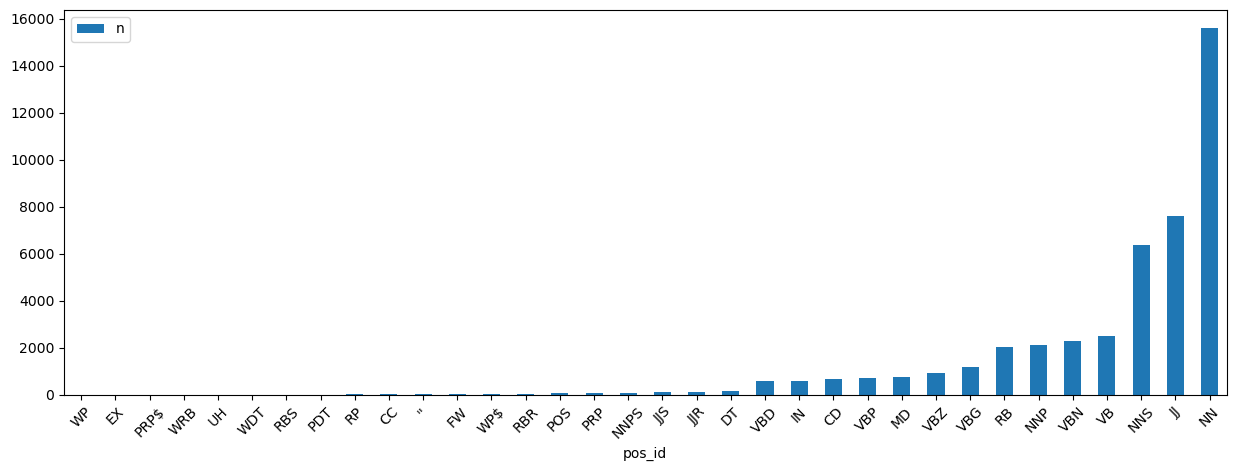

In [230]:
POS.sort_values('n').plot.bar(y='n', figsize=(15,5), rot=45);

# Zipf's Law
## Add term rank to VOCAB

In [231]:
if 'term_rank' not in VOCAB.columns:
    VOCAB = VOCAB.sort_values('n', ascending=False).reset_index()
    VOCAB.index.name = 'term_rank'
    VOCAB = VOCAB.reset_index()
    VOCAB = VOCAB.set_index('term_str')
    VOCAB['term_rank'] = VOCAB['term_rank'] + 1

VOCAB.head()

,term_rank,term_id,n,pos_max,num,stop,p_stem
term_str,,,,,,,
guerrilla,1,3363,355,NN,0,0,guerrilla
must,2,4824,306,MD,0,0,must
one,3,5058,245,CD,0,0,one
capitalist,4,1033,238,JJ,0,0,capitalist
class,5,1235,228,NN,0,0,class


## Alternate Rank

In [232]:
new_rank = VOCAB.n.value_counts()\
    .sort_index(ascending=False).reset_index().reset_index()\
    .rename(columns={'level_0':'term_rank2', 'index':'n', 'n':'nn'})\
    .set_index('n')

new_rank.head()

,nn,count
n,,
0,355,1
1,306,1
2,245,1
3,238,1
4,228,1


In [233]:
VOCAB['term_rank2'] = VOCAB.n.rank(method='dense', ascending=False).astype(int)
VOCAB.head()

,term_rank,term_id,n,pos_max,num,stop,p_stem,term_rank2
term_str,,,,,,,,
guerrilla,1,3363,355,NN,0,0,guerrilla,1
must,2,4824,306,MD,0,0,must,2
one,3,5058,245,CD,0,0,one,3
capitalist,4,1033,238,JJ,0,0,capitalist,4
class,5,1235,228,NN,0,0,class,5


In [234]:
VOCAB['p'] = VOCAB.n / VOCAB.shape[0]

## Compute Zipf's K

In [235]:
VOCAB['zipf_k'] = VOCAB.n * VOCAB.term_rank
VOCAB['zipf_k2'] = VOCAB.n * VOCAB.term_rank2
VOCAB['zipf_k3'] = VOCAB.p * VOCAB.term_rank2

In [236]:
VOCAB.describe().T

,count,mean,std,min,25%,50%,75%,max
term_rank,8290.0,4145.500000,2393.261199,1.000000,2073.250000,4145.500000,6217.750000,8290.000000
term_id,8290.0,4144.500000,2393.261199,0.000000,2072.250000,4144.500000,6216.750000,8289.000000
n,8290.0,5.412063,14.213538,1.000000,1.000000,2.000000,4.000000,355.000000
num,8290.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
stop,8290.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
term_rank2,8290.0,113.862726,11.009564,1.000000,115.000000,117.000000,118.000000,118.000000
p,8290.0,0.000653,0.001715,0.000121,0.000121,0.000241,0.000483,0.042823
zipf_k,8290.0,7311.441737,1439.186360,355.000000,6286.000000,7500.500000,8492.750000,9835.000000
zipf_k2,8290.0,467.365621,659.142350,118.000000,118.000000,234.000000,460.000000,3570.000000
zipf_k3,8290.0,0.056377,0.079511,0.014234,0.014234,0.028227,0.055489,0.430639


## Words with low K

In [237]:
VOCAB[VOCAB.zipf_k <= VOCAB.zipf_k.quantile(.1)].sort_values('zipf_k3', ascending=True).head()

,term_rank,term_id,n,pos_max,num,stop,p_stem,term_rank2,p,zipf_k,zipf_k2,zipf_k3
term_str,,,,,,,,,,,,
spinning,4744,7013,1,VBG,0,0,spin,118,0.000121,4744,118,0.014234
halo,4876,3391,1,NN,0,0,halo,118,0.000121,4876,118,0.014234
searobbers,4877,6589,1,NNS,0,0,searobb,118,0.000121,4877,118,0.014234
associating,4878,559,1,VBG,0,0,associ,118,0.000121,4878,118,0.014234
everchanging,4879,2680,1,JJ,0,0,everchang,118,0.000121,4879,118,0.014234


## Words with high k

In [238]:
VOCAB[VOCAB.zipf_k >= VOCAB.zipf_k.quantile(.9)].sort_values('zipf_k3', ascending=False).head()

,term_rank,term_id,n,pos_max,num,stop,p_stem,term_rank2,p,zipf_k,zipf_k2,zipf_k3
term_str,,,,,,,,,,,,
company,568,1378,16,NN,0,0,compani,103,0.00193,9088,1648,0.198794
revisionism,575,6370,16,NN,0,0,revision,103,0.00193,9200,1648,0.198794
support,579,7308,16,NN,0,0,support,103,0.00193,9264,1648,0.198794
monarchy,578,4746,16,NN,0,0,monarchi,103,0.00193,9248,1648,0.198794
constant,577,1565,16,JJ,0,0,constant,103,0.00193,9232,1648,0.198794


# Visualize

In [239]:
px.histogram(VOCAB, 'zipf_k', marginal='box')

In [240]:
px.histogram(VOCAB, 'zipf_k2', marginal='box')

In [241]:
px.histogram(VOCAB, 'zipf_k3', marginal='box')

## Ranks and N

In [242]:
VSAMP1 = VOCAB[['n','term_rank','zipf_k','term_str','pos_max']]


KeyError: "['term_str'] not in index"

In [ ]:
px.scatter(VSAMP1, x='term_rank', y='n', log_y=False, log_x=False, hover_name='term_str', color='pos_max')

In [ ]:
px.scatter(VSAMP1, x='term_rank', y='n', log_y=True, log_x=True, hover_name='term_str', color='pos_max')

## Demo Rank

In [ ]:
rank_index = [1, 2, 3, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000]

In [ ]:
demo = VOCAB.loc[VOCAB.term_rank.isin(rank_index), ['term_str', 'term_rank', 'n', 'zipf_k', 'pos_max']]

In [ ]:
demo.style.background_gradient(cmap=gradient_cmap, high=.5)

,term_str,term_rank,n,zipf_k,pos_max
term_id,,,,,
3363,guerrilla,1,355,355,NN
4824,must,2,306,612,MD
5058,one,3,245,735,CD
5759,production,10,188,1880,NN
6908,socialism,20,135,2700,NN
5109,order,30,116,3480,NN
2672,even,40,94,3760,RB
3364,guerrillas,50,85,4250,NNS
7390,system,60,74,4440,NN


# Vocab Entropy

In [ ]:
VOCAB['p2'] = VOCAB.n / VOCAB.n.sum()

In [ ]:
VOCAB['h'] = VOCAB.p2 * np.log2(1/VOCAB.p2) # Self entropy of each word 
H = VOCAB.h.sum()
N_v = VOCAB.shape[0]
H_max = np.log2(N_v)
R = round(1 - (H/H_max), 2) * 100

In [ ]:
print("H \t= {}\nH_max \t= {}\nR \t= {}%".format(H, H_max, int(R)))

H 	= 11.468527582874165
H_max 	= 13.017156386383112
R 	= 12%


# BOW

Bag of words is what described the occurences of words within a document and ignores the grammatical word order

In [ ]:
BOW = TOKEN.groupby(bag+['term_str']).term_str.count()\
    .to_frame().rename(columns={'term_str':'n'})

In [ ]:
BOW['c'] = BOW.n.astype('bool').astype('int')

In [ ]:
BOW.head(10)

n  c
book_id            chap_num term_str        
fourier_selections 1        abhorrence  1  1
                            able        1  1
                            absorbing   1  1
                            absurd      1  1
                            abundant    1  1
                            accordance  1  1
                            accorded    1  1
                            according   1  1
                            accounted   2  1
                            acted       1  1

# Document Term Matrix (DTM)

In [ ]:
DTCM = BOW[count_method].unstack().fillna(0).astype('int')

In [ ]:
DTCM = BOW[count_method].unstack().fillna(0).astype('int')
DTCM.head()

term_str                     '  ''  'alert  'area  'as  'base  'class  \
book_id            chap_num                                             
fourier_selections 1         0   0       0      0    0      0       0   
                   2         0   0       0      0    0      0       0   
                   3         0   0       0      0    0      0       0   
                   4         0   0       0      0    0      0       0   
                   5         0   0       0      0    0      0       0   

term_str                     'concentrate  'conservation  'district  ...  \
book_id            chap_num                                          ...   
fourier_selections 1                    0              0          0  ...   
                   2                    0              0          0  ...   
                   3                    0              0          0  ...   
                   4                    0              0          0  ...   
                   5                    0              0          0  ...   

term_str                     yuan  z  zaire  zeal  zealous  zealously  zeit  \
book_id            chap_num                                                   
fourier_selections 1            0  0      0     0        0          0     0   
                   2            0  0      0     0        0          0     0   
                   3            0  0      0     0        0          0     0   
                   4            0  0      0     0        0          0     0   
                   5            0  0      0     0        0          0     0   

term_str                     zeitung  zone  zones  
book_id            chap_num                        
fourier_selections 1               0     0      0  
                   2               0     0      0  
                   3               0     0      0  
                   4               0     0      0  
                   5               0     0      0  

[5 rows x 8290 columns]

In [ ]:
print('TF method:', tf_method)

if tf_method == 'sum':
    TF = DTCM.T / DTCM.T.sum()

elif tf_method == 'max':
    TF = DTCM.T / DTCM.T.max()

elif tf_method == 'log':
    TF = np.log10(1 + DTCM.T)
    
elif tf_method == 'raw':
    TF = DTCM.T

elif tf_method == 'double_norm':
    TF = DTCM.T / DTCM.T.max()
    TF = tf_norm_k + (1 - tf_norm_k) * TF[TF > 0] # EXPLAIN; may defeat purpose of norming

elif tf_method == 'binary':
    TF = DTCM.T.astype('bool').astype('int')
    
TF = TF.T

TF method: sum


In [ ]:
if 'TF' not in globals():
	print('TF not found — computing TF using tf_method:', tf_method)
	if tf_method == 'sum':
		TF = DTCM.T / DTCM.T.sum()
	elif tf_method == 'max':
		TF = DTCM.T / DTCM.T.max()
	elif tf_method == 'log':
		TF = np.log10(1 + DTCM.T)
	elif tf_method == 'raw':
		TF = DTCM.T
	elif tf_method == 'double_norm':
		TF = DTCM.T / DTCM.T.max()
		TF = tf_norm_k + (1 - tf_norm_k) * TF[TF > 0]
	elif tf_method == 'binary':
		TF = DTCM.T.astype('bool').astype('int')
	TF = TF.T
else:
	print('TF already defined — displaying head')
TF.head()

TF already defined — displaying head


term_str                       '   ''  'alert  'area  'as  'base  'class  \
book_id            chap_num                                                
fourier_selections 1         0.0  0.0     0.0    0.0  0.0    0.0     0.0   
                   2         0.0  0.0     0.0    0.0  0.0    0.0     0.0   
                   3         0.0  0.0     0.0    0.0  0.0    0.0     0.0   
                   4         0.0  0.0     0.0    0.0  0.0    0.0     0.0   
                   5         0.0  0.0     0.0    0.0  0.0    0.0     0.0   

term_str                     'concentrate  'conservation  'district  ...  \
book_id            chap_num                                          ...   
fourier_selections 1                  0.0            0.0        0.0  ...   
                   2                  0.0            0.0        0.0  ...   
                   3                  0.0            0.0        0.0  ...   
                   4                  0.0            0.0        0.0  ...   
                   5                  0.0            0.0        0.0  ...   

term_str                     yuan    z  zaire  zeal  zealous  zealously  zeit  \
book_id            chap_num                                                     
fourier_selections 1          0.0  0.0    0.0   0.0      0.0        0.0   0.0   
                   2          0.0  0.0    0.0   0.0      0.0        0.0   0.0   
                   3          0.0  0.0    0.0   0.0      0.0        0.0   0.0   
                   4          0.0  0.0    0.0   0.0      0.0        0.0   0.0   
                   5          0.0  0.0    0.0   0.0      0.0        0.0   0.0   

term_str                     zeitung  zone  zones  
book_id            chap_num                        
fourier_selections 1             0.0   0.0    0.0  
                   2             0.0   0.0    0.0  
                   3             0.0   0.0    0.0  
                   4             0.0   0.0    0.0  
                   5             0.0   0.0    0.0  

[5 rows x 8290 columns]

# Compute DF

In [ ]:
DF = DTCM[DTCM > 0].count()
DF = DTCM[DTCM > 0].count()
DF.head()

term_str
'         6
''        2
'alert    1
'area     1
'as       1
dtype: int64

# Comput IDF

In [ ]:
N = DTCM.shape[0]

print('IDF method:', idf_method)

if idf_method == 'standard':
    IDF = np.log10(N / DF)

elif idf_method == 'max':
    IDF = np.log10(DF.max() / DF) 

elif idf_method == 'smooth':
    IDF = np.log10((1 + N) / (1 + DF)) + 1 # Correct?

IDF method: standard


# Compute TF IDF

In [ ]:
TFIDF = TF * IDF

In [ ]:
TFIDF.head()

term_str                       '   ''  'alert  'area  'as  'base  'class  \
book_id            chap_num                                                
fourier_selections 1         0.0  0.0     0.0    0.0  0.0    0.0     0.0   
                   2         0.0  0.0     0.0    0.0  0.0    0.0     0.0   
                   3         0.0  0.0     0.0    0.0  0.0    0.0     0.0   
                   4         0.0  0.0     0.0    0.0  0.0    0.0     0.0   
                   5         0.0  0.0     0.0    0.0  0.0    0.0     0.0   

term_str                     'concentrate  'conservation  'district  ...  \
book_id            chap_num                                          ...   
fourier_selections 1                  0.0            0.0        0.0  ...   
                   2                  0.0            0.0        0.0  ...   
                   3                  0.0            0.0        0.0  ...   
                   4                  0.0            0.0        0.0  ...   
                   5                  0.0            0.0        0.0  ...   

term_str                     yuan    z  zaire  zeal  zealous  zealously  zeit  \
book_id            chap_num                                                     
fourier_selections 1          0.0  0.0    0.0   0.0      0.0        0.0   0.0   
                   2          0.0  0.0    0.0   0.0      0.0        0.0   0.0   
                   3          0.0  0.0    0.0   0.0      0.0        0.0   0.0   
                   4          0.0  0.0    0.0   0.0      0.0        0.0   0.0   
                   5          0.0  0.0    0.0   0.0      0.0        0.0   0.0   

term_str                     zeitung  zone  zones  
book_id            chap_num                        
fourier_selections 1             0.0   0.0    0.0  
                   2             0.0   0.0    0.0  
                   3             0.0   0.0    0.0  
                   4             0.0   0.0    0.0  
                   5             0.0   0.0    0.0  

[5 rows x 8290 columns]

In [ ]:
VOCAB['df'] = DF
VOCAB['idf'] = IDF

In [ ]:
VOCAB.head()

,term_rank,term_str,n,pos_max,num,stop,p_stem,term_rank2,p,zipf_k,zipf_k2,zipf_k3,p2,h,df,idf
term_id,,,,,,,,,,,,,,,,
3363,1,guerrilla,355,NN,0,0,guerrilla,1,0.042823,355,355,0.042823,0.007912,0.055242,NaN,NaN
4824,2,must,306,MD,0,0,must,2,0.036912,612,612,0.073824,0.006820,0.049079,NaN,NaN
5058,3,one,245,CD,0,0,one,3,0.029554,735,735,0.088661,0.005461,0.041046,NaN,NaN
1033,4,capitalist,238,JJ,0,0,capitalist,4,0.028709,952,952,0.114837,0.005305,0.040096,NaN,NaN
1235,5,class,228,NN,0,0,class,5,0.027503,1140,1140,0.137515,0.005082,0.038726,NaN,NaN


In [ ]:
BOW['tf'] = TF.stack()
BOW['tfidf'] = TFIDF.stack()

In [ ]:
BOW.head()

n  c        tf     tfidf
book_id            chap_num term_str                            
fourier_selections 1        abhorrence  1  1  0.000657  0.001110
                            able        1  1  0.000657  0.000256
                            absorbing   1  1  0.000657  0.001110
                            absurd      1  1  0.000657  0.000912
                            abundant    1  1  0.000657  0.001110

In [ ]:
VOCAB['tfidf_sum'] = TFIDF.sum()

In [ ]:
VOCAB.sort_values('tfidf_sum', ascending=False).head(20).style.background_gradient(cmap=gradient_cmap, high=1)

/Users/samanthaasefi/miniconda3/envs/myenv/lib/python3.13/site-packages/pandas/io/formats/style.py:3807: RuntimeWarning:

All-NaN slice encountered

/Users/samanthaasefi/miniconda3/envs/myenv/lib/python3.13/site-packages/pandas/io/formats/style.py:3808: RuntimeWarning:

All-NaN slice encountered



,term_rank,term_str,n,pos_max,num,stop,p_stem,term_rank2,p,zipf_k,zipf_k2,zipf_k3,p2,h,df,idf,tfidf_sum
term_id,,,,,,,,,,,,,,,,,
3363,1,guerrilla,355,NN,0,0,guerrilla,1,0.042823,355,355,0.042823,0.007912,0.055242,nan,nan,nan
4824,2,must,306,MD,0,0,must,2,0.036912,612,612,0.073824,0.006820,0.049079,nan,nan,nan
5058,3,one,245,CD,0,0,one,3,0.029554,735,735,0.088661,0.005461,0.041046,nan,nan,nan
1033,4,capitalist,238,JJ,0,0,capitalist,4,0.028709,952,952,0.114837,0.005305,0.040096,nan,nan,nan
1235,5,class,228,NN,0,0,class,5,0.027503,1140,1140,0.137515,0.005082,0.038726,nan,nan,nan
6901,6,social,210,JJ,0,0,social,6,0.025332,1260,1260,0.151990,0.004681,0.036224,nan,nan,nan
6918,7,society,203,NN,0,0,societi,7,0.024487,1421,1421,0.171411,0.004525,0.035237,nan,nan,nan
5343,8,people,201,NNS,0,0,peopl,8,0.024246,1608,1608,0.193969,0.004480,0.034954,nan,nan,nan
2061,9,development,192,NN,0,0,develop,9,0.023160,1728,1728,0.208444,0.004279,0.033672,nan,nan,nan


In [ ]:
VOCAB[['term_rank','term_str','pos_max','tfidf_sum']]\
    .sort_values('tfidf_sum', ascending=False).head(50)\
    .style.background_gradient(cmap=gradient_cmap, high=1)

/Users/samanthaasefi/miniconda3/envs/myenv/lib/python3.13/site-packages/pandas/io/formats/style.py:3807: RuntimeWarning:

All-NaN slice encountered

/Users/samanthaasefi/miniconda3/envs/myenv/lib/python3.13/site-packages/pandas/io/formats/style.py:3808: RuntimeWarning:

All-NaN slice encountered



,term_rank,term_str,pos_max,tfidf_sum
term_id,,,,
3363,1,guerrilla,NN,nan
4824,2,must,MD,nan
5058,3,one,CD,nan
1033,4,capitalist,JJ,nan
1235,5,class,NN,nan
6901,6,social,JJ,nan
6918,7,society,NN,nan
5343,8,people,NNS,nan
2061,9,development,NN,nan


In [ ]:
VOCAB.loc[VOCAB.pos_max != 'NNP', ['term_rank','term_str','pos_max','tfidf_sum']]\
    .sort_values('tfidf_sum', ascending=False)\
    .head(50).style.background_gradient(cmap=gradient_cmap, high=1)

/Users/samanthaasefi/miniconda3/envs/myenv/lib/python3.13/site-packages/pandas/io/formats/style.py:3807: RuntimeWarning:

All-NaN slice encountered

/Users/samanthaasefi/miniconda3/envs/myenv/lib/python3.13/site-packages/pandas/io/formats/style.py:3808: RuntimeWarning:

All-NaN slice encountered



,term_rank,term_str,pos_max,tfidf_sum
term_id,,,,
3363,1,guerrilla,NN,nan
4824,2,must,MD,nan
5058,3,one,CD,nan
1033,4,capitalist,JJ,nan
1235,5,class,NN,nan
6901,6,social,JJ,nan
6918,7,society,NN,nan
5343,8,people,NNS,nan
2061,9,development,NN,nan


In [ ]:
def tfidf_matrix(
    tokens: pd.DataFrame,
    bag: list,
    count_method: str = "n",
    tf_method: str = "sum",
    idf_method: str = "standard",
) -> pd.DataFrame:
    bow = tokens.groupby(bag + ["term_str"]).size().rename("n").to_frame()
    bow["c"] = bow["n"].astype(bool).astype(int)

    if count_method == "binary":
        dtm = bow["c"].unstack().fillna(0).astype(int)
    else:
        dtm = bow["n"].unstack().fillna(0).astype(int)

    N = dtm.shape[0]
    df = dtm[dtm > 0].count()

    if tf_method == "sum":
        tf = (dtm.T / dtm.T.sum()).T
    elif tf_method == "max":
        tf = (dtm.T / dtm.T.max()).T
    elif tf_method == "log":
        tf = np.log10(1 + dtm)
    elif tf_method == "raw":
        tf = dtm
    elif tf_method == "binary":
        tf = dtm.astype(bool).astype(int)
    else:
        tf = dtm

    if idf_method == "standard":
        idf = np.log10(N / df)
    elif idf_method == "max":
        idf = np.log10(df.max() / df)
    elif idf_method == "smooth":
        idf = np.log10((1 + N) / (1 + df)) + 1

    return tf * idf

TFIDF_books = tfidf_matrix(TOKEN, bag=BOOKS, count_method="n", tf_method="sum", idf_method="standard")
TFIDF_books